- Hourse price ~ Lot size + Location + (Lot Size * Location)

- “A big house in a bad area is not expensive.
A small house in a great area is not ultra-expensive.
But a big house in a great area — that’s where the price explodes.”

- That “explosion” is what the interaction term captures.

   house_size_sqm  location_quality  size_x_location  price_$1000s
0              50                 2              100          50.0
1              70                 3              210          75.5
2              90                 4              360         103.0
3             110                 3              330         101.5
4             130                 5              650         147.5
5             150                 4              600         145.0


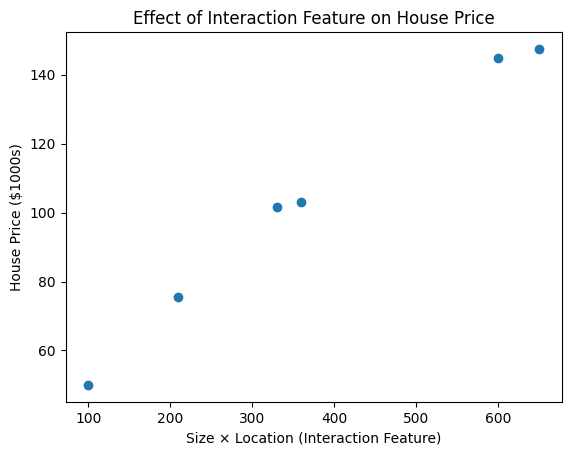

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# example: House size and location quality affecting price

#  dataset
data = {
    "house_size_sqm": [50, 70, 90, 110, 130, 150],
    "location_quality": [2, 3, 4, 3, 5, 4]  # 1 (poor) to 5 (excellent)
}

df = pd.DataFrame(data)

# Create interaction feature
df["size_x_location"] = df["house_size_sqm"] * df["location_quality"]

# Simulated house price (target)
df["price_$1000s"] = (
    0.5 * df["house_size_sqm"] +
    10 * df["location_quality"] +
    0.05 * df["size_x_location"]
)

print(df)

# Plot interaction vs price
plt.figure()
plt.scatter(df["size_x_location"], df["price_$1000s"])
plt.xlabel("Size × Location (Interaction Feature)")
plt.ylabel("House Price ($1000s)")
plt.title("Effect of Interaction Feature on House Price")
plt.show()


- When interaction truly exists:

  - Omitting it → biased coefficients

  - Including it → interpretable, correct parameters

- “If reality multiplies features, your model must multiply them too.”

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
# ----------------------------
# 2. Model WITHOUT interaction
# ----------------------------
X1 = df[["house_size_sqm", "location_quality"]]
y = df["price_$1000s"]

model_without = LinearRegression()
model_without.fit(X1, y)

print("=== Model WITHOUT Interaction ===")
print("Intercept:", model_without.intercept_)
print("Coefficients:")
for feature, coef in zip(X1.columns, model_without.coef_):
    print(f"{feature}: {coef:.4f}")

# ----------------------------
# 3. Model WITH interaction
# ----------------------------
X2 = df[["house_size_sqm", "location_quality", "size_x_location"]]

model_with = LinearRegression()
model_with.fit(X2, y)

print("\n=== Model WITH Interaction ===")
print("Intercept:", model_with.intercept_)
print("Coefficients:")
for feature, coef in zip(X2.columns, model_with.coef_):
    print(f"{feature}: {coef:.4f}")


=== Model WITHOUT Interaction ===
Intercept: -14.937499999999957
Coefficients:
house_size_sqm: 0.6662
location_quality: 14.8750

=== Model WITH Interaction ===
Intercept: -1.1368683772161603e-13
Coefficients:
house_size_sqm: 0.5000
location_quality: 10.0000
size_x_location: 0.0500
